<a href="https://colab.research.google.com/github/annagrenz/ChangeInStockPricePrediction_withTweetSentimentAnalysis/blob/main/FlowerPower.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stock Price Predictions with Convolutional Neural Networks and Natural Language Processing**

This notebook is for anyone interested in diving deeper into the world of stock price change predictions using deep learning. As prior knowledge about neural networks and text analysis is expected, our target audience is people who are interested in learning more about the technical aspects and implementation of the model.

# Introduction



The aim of this project was to replicate the model proposed in the paper "Siamese Graph Convolutional Split‑Attention Network with NLP based Social Sentimental Data for enhanced stock price predictions" by Kumarappan et al. (2024).

Predicting stock prices is a hot topic in finance, but it is very challenging to assess due to noisy and volatile data (Kumarappan et al., 2024). Some theories, such as the efficient market hypothesis, even suggest that it is impossible to predict stock prices based on historical data, because it assumes that all the information available is already included in the price and therefore accessible to everbody. However, the introduction of neural networks has drastically improved stock price predictions through time series analysis. Various papers suggest that transformer models in particular are well suited for stock price predictions, given their ability to account for temporal patterns and adapt to dynamic changes (e.g. Qian, 2025).
Additionally, with the growing influence and prevalence of social media, text processing has also become an increasingly important predictor of stock prices. The paper by Kumarappan et al. (2024) presents a novel approach of predicting the change of stock prices by combining historical stock prices data with social sentimental data.

Our goal for this project was to replicate the study by Kumarappan et al. (2024). As a guide we used the code that is available on GitHub (https://github.com/jramans2/Siamese-GCN-SplitAttention-Stock-Prediction.git). Since this study used PyTorch we wanted to maximize our learning experience by translating the code into Keras.

The graph below shows a visualization of the procedure.

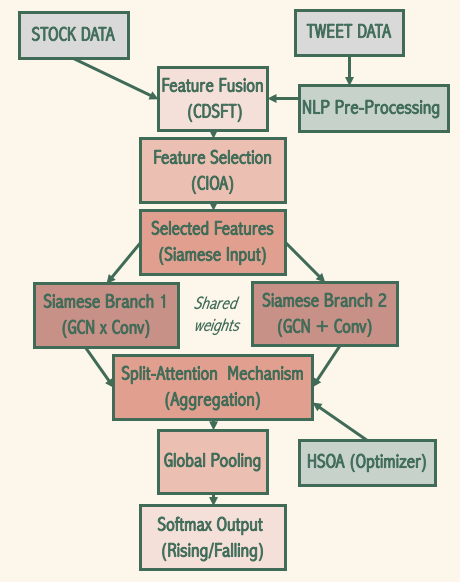

Disclaimer:
Large Language Models, specifically ChatGPT and Google Gemini, were used to support the initial comprehension of the provided codebase, including the identification and interpretation of components implemented in PyTorch.

# Setup & Imports


In [ ]:
tweets_all = "https://raw.githubusercontent.com/llaser00/Flower-Power-DLiP/refs/heads/main/stock_tweets.csv"
stocks_all = "https://raw.githubusercontent.com/llaser00/Flower-Power-DLiP/refs/heads/main/stock_yfinance_data.csv"

In [ ]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import BinaryAccuracy
from tensorflow.keras.callbacks import History
import os
import random
import re
import time
import warnings
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from nltk import download as nltk_download
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, mean_absolute_error, mean_squared_error, precision_score, recall_score, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
stocks_full = pd.read_csv(stocks_all)
tweets = pd.read_csv(tweets_all)

## Data Exploration

In [ ]:
stocks_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6300 entries, 0 to 6299
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        6300 non-null   object 
 1   Open        6300 non-null   float64
 2   High        6300 non-null   float64
 3   Low         6300 non-null   float64
 4   Close       6300 non-null   float64
 5   Adj Close   6300 non-null   float64
 6   Volume      6300 non-null   int64  
 7   Stock Name  6300 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 393.9+ KB


In [ ]:
print(tweets['Stock Name'].unique())
len(tweets['Stock Name'].unique())
tweets['Stock Name'].value_counts().head(6)

['TSLA' 'MSFT' 'PG' 'META' 'AMZN' 'GOOG' 'AMD' 'AAPL' 'NFLX' 'TSM' 'KO'
 'F' 'COST' 'DIS' 'VZ' 'CRM' 'INTC' 'BA' 'BX' 'NOC' 'PYPL' 'ENPH' 'NIO'
 'ZS' 'XPEV']


,count
Stock Name,
TSLA,37422
TSM,11034
AAPL,5056
AMZN,4089
MSFT,4089
PG,4089


As this code only processes one stock at a time, we focused on Tesla (TSLA) stocks, as Tesla had the largest number of company-specific tweets.

In [ ]:
stocks = stocks_full[stocks_full["Stock Name"] == "TSLA"].copy()

print(f"[Explore] Stocks shape: {stocks.shape}")
print(f"[Explore] Tweets shape: {tweets.shape}")

[Explore] Stocks shape: (252, 8)
[Explore] Tweets shape: (80793, 4)


In [ ]:
print("[Explore] Stock dtypes:", stocks.dtypes)
print("[Explore] Stock describe():", stocks.describe(include="all").transpose().head())
print("[Explore] Tweets head:", tweets.head())

stocks_plot = stocks.copy()
stocks_plot["Date"] = pd.to_datetime(stocks_plot["Date"])

[Explore] Stock dtypes: Date           object
Open          float64
High          float64
Low           float64
Close         float64
Adj Close     float64
Volume          int64
Stock Name     object
dtype: object
[Explore] Stock describe():        count unique         top freq        mean        std         min  \
Date     252    252  2021-09-30    1         NaN        NaN         NaN   
Open   252.0    NaN         NaN  NaN  300.295542   46.16112  207.949997   
High   252.0    NaN         NaN  NaN  307.656601  46.804121  217.973328   
Low    252.0    NaN         NaN  NaN  292.253823  44.718813  206.856674   
Close  252.0    NaN         NaN  NaN  299.864947  45.812123  209.386673   

              25%         50%         75%         max  
Date          NaN         NaN         NaN         NaN  
Open   266.860825      298.75  335.700005  411.470001  
High   273.241661  304.158325  344.957512  414.496674  
Low    260.780823  289.565002   327.90834  405.666656  
Close  267.203331  296.8566

# Preprocessing

In the following, we download the required NLTK resources and define a cleaning function that lowercases tweets, removes URLs and non-letter characters, removes stopwords and short tokens, and lemmatizes the remaining words. We then compute VADER sentiment scores (compound, positive, neutral, negative) for each cleaned tweet and construct TF–IDF features by keeping the 25 most informative words.
In parallel, we preprocess the stock data by converting and sorting dates, preserving the raw closing price, scaling numeric financial features to ([0,1]), and engineering daily returns and a 3-day rolling volatility. Finally, we aggregate sentiment and TF–IDF features to the daily level, merge them with the daily stock data by date, fill missing values with zeros, and define separate lists of financial and sentiment/text feature columns for later modeling.


In [ ]:
for resource in ["vader_lexicon", "stopwords", "punkt", "punkt_tab", "wordnet", "omw-1.4"]:
    nltk_download(resource, quiet=True)
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))


def _clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [lemmatizer.lemmatize(tok) for tok in word_tokenize(text) if tok not in stop_words and len(tok) > 2]
    return " ".join(tokens)

tweets["clean_text"] = tweets["Tweet"].astype(str).apply(_clean_text)
sia = SentimentIntensityAnalyzer()
tweets["compound"] = tweets["clean_text"].apply(lambda t: sia.polarity_scores(t)["compound"])
tweets["pos"] = tweets["clean_text"].apply(lambda t: sia.polarity_scores(t)["pos"])
tweets["neu"] = tweets["clean_text"].apply(lambda t: sia.polarity_scores(t)["neu"])
tweets["neg"] = tweets["clean_text"].apply(lambda t: sia.polarity_scores(t)["neg"])

tfidf = TfidfVectorizer(max_features=25, stop_words="english")
tfidf_matrix = tfidf.fit_transform(tweets["clean_text"])
tfidf_cols = [f"tfidf_{w}" for w in tfidf.get_feature_names_out()]
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_cols)
tfidf_df["Date"] = tweets["Date"].values

stocks["Date"] = pd.to_datetime(stocks["Date"]).dt.date
stocks = stocks.sort_values("Date").reset_index(drop=True)
stocks["Close_raw"] = stocks["Close"].astype(float)
numeric_cols = [c for c in stocks.columns if c not in ["Date", "Stock Name", "Close_raw"]]
scaler = MinMaxScaler()
stocks[numeric_cols] = scaler.fit_transform(stocks[numeric_cols])
stocks["Daily_Return"] = stocks["Close_raw"].pct_change().fillna(0)
stocks["Volatility_3d"] = stocks["Close_raw"].pct_change().rolling(3).std().fillna(0)
print(f"[Preprocess] Financial features after scaling: {stocks.head(3)}")

tweets["Date"] = pd.to_datetime(tweets["Date"]).dt.date
sentiment_grouped = tweets.groupby("Date")[['compound','pos','neu','neg']].mean().reset_index()
tfidf_grouped = tfidf_df.groupby("Date").mean().reset_index()
sentiment_features = sentiment_grouped.merge(tfidf_grouped, on="Date", how="left").fillna(0)

fused = stocks.merge(sentiment_features, on="Date", how="left").fillna(0)
print(f"[Preprocess] Aligned daily fused dataframe shape: {fused.shape}")
print(f"[Preprocess] Fused sample:{fused.head(2)}")

financial_cols = ["Open","High","Low","Close","Adj Close","Volume","Daily_Return","Volatility_3d"]
sentiment_cols = ["compound","pos","neu","neg"] + tfidf_cols

[Preprocess] Financial features after scaling:          Date      Open      High       Low     Close  Adj Close    Volume  \
0  2021-09-30  0.257387  0.229337  0.258924  0.244819   0.244819  0.122630   
1  2021-10-01  0.253128  0.215174  0.239793  0.244387   0.244387  0.104561   
2  2021-10-04  0.282773  0.259596  0.260802  0.254873   0.254873  0.367441   

  Stock Name   Close_raw  Daily_Return  Volatility_3d  
0       TSLA  258.493347      0.000000            0.0  
1       TSLA  258.406677     -0.000335            0.0  
2       TSLA  260.510010      0.008140            0.0  
[Preprocess] Aligned daily fused dataframe shape: (252, 40)
[Preprocess] Fused sample:         Date      Open      High       Low     Close  Adj Close    Volume  \
0  2021-09-30  0.257387  0.229337  0.258924  0.244819   0.244819  0.122630   
1  2021-10-01  0.253128  0.215174  0.239793  0.244387   0.244387  0.104561   

  Stock Name   Close_raw  Daily_Return  ...  tfidf_share  tfidf_spy  \
0       TSLA  258.493347

# Train / test split

We construct the prediction target and prepare the data for modeling. We define a binary target variable that indicates whether the stock’s closing price on day (t+1) is higher than on day (t). Because this target is created by shifting the series forward, we remove the last observation, which has no valid label, and reset the indices. We then extract the financial and sentiment feature blocks from the fused dataset and convert them, together with the target, into NumPy arrays to ensure compatibility with the subsequent models. Finally, we perform a chronological 80/20 train–test split, using the first 80% of observations for training and the remaining 20% for testing, and report the resulting dataset dimensions.


In [ ]:
### exploring ###
fused.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Stock Name,Close_raw,Daily_Return,...,tfidf_share,tfidf_spy,tfidf_stock,tfidf_tesla,tfidf_time,tfidf_today,tfidf_tsla,tfidf_tsm,tfidf_week,tfidf_year
0,2021-09-30,0.257387,0.229337,0.258924,0.244819,0.244819,0.122630,TSLA,258.493347,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2021-10-01,0.253128,0.215174,0.239793,0.244387,0.244387,0.104561,TSLA,258.406677,-0.000335,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2021-10-04,0.282773,0.259596,0.260802,0.254873,0.254873,0.367441,TSLA,260.510010,0.008140,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2021-10-05,0.263610,0.243211,0.257583,0.253311,0.253311,0.131943,TSLA,260.196655,-0.001203,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2021-10-06,0.249525,0.225147,0.255939,0.256901,0.256901,0.057687,TSLA,260.916656,0.002767,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
target = (fused["Close_raw"].shift(-1) > fused["Close_raw"]).astype(int)
fused = fused[:-1].reset_index(drop=True)
target = target[:-1].reset_index(drop=True)
X_fin = fused[financial_cols].values
X_sent = fused[sentiment_cols].values
y = target.values
idx_split = int(len(fused) * 0.8)
X_fin_train, X_fin_test = X_fin[:idx_split], X_fin[idx_split:]
X_sent_train, X_sent_test = X_sent[:idx_split], X_sent[idx_split:]
y_train, y_test = y[:idx_split], y[idx_split:]

print(f"[Split] Train sizes: fin={X_fin_train.shape}, sent={X_sent_train.shape}, y={y_train.shape}")
print(f"[Split] Test sizes: fin={X_fin_test.shape}, sent={X_sent_test.shape}, y={y_test.shape}")

[Split] Train sizes: fin=(200, 8), sent=(200, 29), y=(200,)
[Split] Test sizes: fin=(51, 8), sent=(51, 29), y=(51,)


# Feature Enginnering
## Cross-Domain Swin Fusion Transformer (CDSFT) Feature Fusion

We define and instantiate a cross-domain fusion module that combines financial and sentiment features using a transformer-based architecture. We take financial and sentiment inputs separately, project both into a shared latent space, and stack them as a short sequence representing two information domains. We then apply one or more transformer encoder layers with multi-head self-attention and feed-forward blocks to model interactions between the financial and sentiment representations. After attention-based fusion, we aggregate the sequence with global average pooling and additionally include a direct linear fusion of the original projected features. The resulting combined representation is returned as a unified feature vector, and we verify its dimensionality by passing a small training batch through the fusion block.


In [ ]:
def create_cross_domain_swin_fusion_transformer_keras(fin_dim, sent_dim, model_dim=64, num_heads=4, num_layers=2): #
    fin_input = keras.Input(shape=(fin_dim,), name='financial_input')
    sent_input = keras.Input(shape=(sent_dim,), name='sentiment_input')
    fin_h = layers.Dense(model_dim, name='fin_projection')(fin_input)
    sent_h = layers.Dense(model_dim, name='sent_projection')(sent_input)
    fin_expanded = layers.Lambda(lambda x: tf.expand_dims(x, axis=1), name='fin_expand')(fin_h)
    sent_expanded = layers.Lambda(lambda x: tf.expand_dims(x, axis=1), name='sent_expand')(sent_h)
    sequence = layers.Concatenate(axis=1, name='domain_stack')([fin_expanded, sent_expanded])

    # transformer-encoder
    encoded = sequence
    for i in range(num_layers):
        # Multi-Head Attention Block
        attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=model_dim)(encoded, encoded)
        encoded = layers.Add(name=f'attn_add_{i}')([encoded, attn_output])
        encoded = layers.LayerNormalization(epsilon=1e-6, name=f'norm1_{i}')(encoded)
        # Feed-Forward Network Block
        ff_output = layers.Dense(model_dim * 2, activation='relu')(encoded)
        ff_output = layers.Dense(model_dim)(ff_output)
        encoded = layers.Add(name=f'ff_add_{i}')([encoded, ff_output])
        encoded = layers.LayerNormalization(epsilon=1e-6, name=f'norm2_{i}')(encoded)

    pooled = layers.GlobalAveragePooling1D(name='pooled_features')(encoded)
    concatenated = layers.Concatenate(axis=-1, name='projected_concat')([fin_h, sent_h])
    fused = layers.Dense(model_dim, name='linear_fused_output')(concatenated)
    final_output = layers.Concatenate(axis=-1, name='final_fused_features')([pooled, fused])
    model = Model(inputs=[fin_input, sent_input], outputs=final_output, name='CrossDomainSwinFusionTransformer_Keras')
    return model

In [ ]:
fin_dim = X_fin_train.shape[1]  # number of columns in our financial data
sent_dim = X_sent_train.shape[1] # number of columns in our sentiment data

fusion_block = create_cross_domain_swin_fusion_transformer_keras(
    fin_dim=fin_dim,
    sent_dim=sent_dim,
    model_dim=32,
    num_heads=4,
    num_layers=1
)

sample_fin_keras = X_fin_train[:8]
sample_sent_keras = X_sent_train[:8]

fused_preview = fusion_block({'financial_input': sample_fin_keras, 'sentiment_input': sample_sent_keras})

print(f"[CDSFT] Preview fused shape on mini-batch: {tuple(fused_preview.shape.as_list())}")

[CDSFT] Preview fused shape on mini-batch: (8, 64)


## Circle-Inspired Optimization Algorithm (CIOA) Feature Selection

In the following, we perform a feature selection procedure across the financial and sentiment domains. We repeatedly sample different subsets of financial and sentiment features, concatenate them, and evaluate their predictive usefulness using a logistic regression model on a train–validation split. Across multiple iterations, we track the feature subsets that yield the highest validation accuracy. Finally, we retain the best-performing financial and sentiment feature indices, map them back to their original feature names, and construct reduced training and test datasets containing only the selected features.


In [ ]:
rng = np.random.default_rng(42)
best_score = -1
best_fin_idx = np.arange(X_fin_train.shape[1])
best_sent_idx = np.arange(X_sent_train.shape[1])
for i in range(12):
    angle = np.linspace(0, 2 * np.pi, num=max(4, min(12, X_fin_train.shape[1])), endpoint=False)
    fin_idx = np.unique(((np.abs(np.sin(angle)) * X_fin_train.shape[1])).astype(int)) % X_fin_train.shape[1]
    sent_choice = rng.choice(X_sent_train.shape[1], size=max(8, X_sent_train.shape[1] // 2), replace=False)
    X_fin_sub = X_fin_train[:, fin_idx]
    X_sent_sub = X_sent_train[:, sent_choice]
    X_concat = np.hstack([X_fin_sub, X_sent_sub])
    stratify_target = y_train if len(np.unique(y_train)) > 1 else None
    X_tr, X_val, y_tr, y_val = train_test_split(X_concat, y_train, test_size=0.2, random_state=i, stratify=stratify_target)
    clf = LogisticRegression(max_iter=250)
    clf.fit(X_tr, y_tr)
    score = clf.score(X_val, y_val)
    if score > best_score:
        best_score = score
        best_fin_idx = fin_idx
        best_sent_idx = sent_choice
    print(f"[CIOA] Iteration {i+1}/12 validation accuracy: {score:.3f}")

fin_names = [financial_cols[i] for i in best_fin_idx]
sent_names = [sentiment_cols[i] for i in best_sent_idx]
print(f"[CIOA] Selected financial features: {fin_names}")
print(f"[CIOA] Selected sentiment features: {sent_names}")

X_fin_sel_train = X_fin_train[:, best_fin_idx]
X_sent_sel_train = X_sent_train[:, best_sent_idx]
X_fin_sel_test = X_fin_test[:, best_fin_idx]
X_sent_sel_test = X_sent_test[:, best_sent_idx]
print(f"[Select] Train shapes -> fin: {X_fin_sel_train.shape}, sent: {X_sent_sel_train.shape}")
print(f"[Select] Test shapes  -> fin: {X_fin_sel_test.shape}, sent: {X_sent_sel_test.shape}")
print(f"[Select] Sample train row (fin): {X_fin_sel_train[0] if len(X_fin_sel_train)>0 else 'n/a'}")
print(f"[Select] Sample train row (sent): {X_sent_sel_train[0] if len(X_sent_sel_train)>0 else 'n/a'}")

[CIOA] Iteration 1/12 validation accuracy: 0.500
[CIOA] Iteration 2/12 validation accuracy: 0.700
[CIOA] Iteration 3/12 validation accuracy: 0.425
[CIOA] Iteration 4/12 validation accuracy: 0.425
[CIOA] Iteration 5/12 validation accuracy: 0.500
[CIOA] Iteration 6/12 validation accuracy: 0.450
[CIOA] Iteration 7/12 validation accuracy: 0.525
[CIOA] Iteration 8/12 validation accuracy: 0.500
[CIOA] Iteration 9/12 validation accuracy: 0.550
[CIOA] Iteration 10/12 validation accuracy: 0.500
[CIOA] Iteration 11/12 validation accuracy: 0.550
[CIOA] Iteration 12/12 validation accuracy: 0.575
[CIOA] Selected financial features: ['Open', 'Volume', 'Open']
[CIOA] Selected sentiment features: ['tfidf_amzn', 'pos', 'tfidf_elon', 'tfidf_year', 'tfidf_day', 'tfidf_like', 'tfidf_time', 'tfidf_spy', 'tfidf_tsm', 'tfidf_nio', 'tfidf_market', 'tfidf_aapl', 'tfidf_stock', 'tfidf_tsla']
[Select] Train shapes -> fin: (200, 3), sent: (200, 14)
[Select] Test shapes  -> fin: (51, 3), sent: (51, 14)
[Select] Sa

# Humboldt Squid Optimization Algorithm (HSOA) Hyperparameter Search

Here we build and tune a hybrid graph–attention–transformer model for predicting the binary target. We first define a custom Keras graph-convolution layer (SimpleGraphConvKeras) that propagates information using an adjacency matrix and then applies a linear layer plus ReLU. Using this, we create a model (create_siagracon_sa_keras) that learns separate graph-based embeddings for financial and sentiment features, fuses the two domains again with the previously defined cross-domain transformer block, and learns attention weights (a softmax over two weights) to mix the financial and sentiment graph embeddings before combining them with the transformer-fused representation and producing a final logit.

We then split the training data chronologically into an inner-train and validation set, construct static adjacency matrices for each domain from feature–feature correlations (with NaNs handled, a small self-loop term added, and row-normalization), and convert them to tensors. Finally, we run a random hyperparameter search over a few candidate settings (learning rate, hidden size, fusion dimension, dropout), train each model briefly, evaluate validation loss, and keep the best-performing parameter set.


In [ ]:
class SimpleGraphConvKeras(layers.Layer):
    """Replicates the SimpleGraphConv: message = X @ A, output = ReLU(Linear(message))"""
    def __init__(self, out_dim: int, **kwargs):
        super().__init__(**kwargs)
        self.out_dim = out_dim
        self.linear = None

    def build(self, input_shape):
        in_dim = input_shape[0][-1]
        self.linear = layers.Dense(self.out_dim, use_bias=True, name='gcn_linear')
        super().build(input_shape)

    def call(self, inputs):
        x, adjacency = inputs
        x_expanded = tf.expand_dims(x, axis=1)
        message_expanded = tf.matmul(x_expanded, adjacency)
        message = tf.squeeze(message_expanded, axis=1)

        output = self.linear(message)
        return tf.nn.relu(output)

    def get_config(self):
        config = super().get_config()
        config.update({"out_dim": self.out_dim})
        return config

In [ ]:
def create_siagracon_sa_keras(fin_dim: int, sent_dim: int, fusion_dim: int, hidden: int, dropout: float = 0.2):
    fin_input = keras.Input(shape=(fin_dim,), name='fin_features')
    sent_input = keras.Input(shape=(sent_dim,), name='sent_features')
    fin_adj_input = keras.Input(shape=(fin_dim, fin_dim), name='fin_adjacency')
    sent_adj_input = keras.Input(shape=(sent_dim, sent_dim), name='sent_adjacency')

    fin_g = SimpleGraphConvKeras(out_dim=hidden, name='fin_gcn')([fin_input, fin_adj_input])
    sent_g = SimpleGraphConvKeras(out_dim=hidden, name='sent_gcn')([sent_input, sent_adj_input])
    fusion_model = create_cross_domain_swin_fusion_transformer_keras(fin_dim, sent_dim, model_dim=fusion_dim, num_heads=4, num_layers=2)
    fused = fusion_model({'financial_input': fin_input, 'sentiment_input': sent_input})
    attn_input = layers.Concatenate(axis=-1, name='attn_input')([fin_g, sent_g, fused])

    attn_weights = layers.Dense(hidden, activation='relu')(attn_input)
    attn_weights = layers.Dropout(dropout)(attn_weights)
    attn_weights = layers.Dense(2, activation='softmax', name='attention_weights')(attn_weights)

    fin_weight = layers.Lambda(lambda x: x[:, 0:1])(attn_weights)
    sent_weight = layers.Lambda(lambda x: x[:, 1:2])(attn_weights)

    mixed_fin = layers.Multiply()([fin_weight, fin_g])
    mixed_sent = layers.Multiply()([sent_weight, sent_g])
    mixed = layers.Add(name='mixed_gcn_output')([mixed_fin, mixed_sent])

    classifier_input = layers.Concatenate(axis=-1, name='classifier_input')([mixed, fused])

    logits = layers.Dense(hidden, activation='relu')(classifier_input)
    logits = layers.Dropout(dropout)(logits)
    logits = layers.Dense(1, name='output_logits')(logits)

    model = Model(
        inputs=[fin_input, sent_input, fin_adj_input, sent_adj_input],
        outputs=logits,
        name='SiagraConSA_Keras'
    )
    return model

In [ ]:
# Helper Function for our time series analysis - ensures temporal order of the data
def _time_order_split(Xf, Xs, labels, val_ratio=0.2):
    cut = int(len(labels) * (1 - val_ratio))
    return (Xf[:cut], Xs[:cut], labels[:cut]), (Xf[cut:], Xs[cut:], labels[cut:])

y_train_keras = y_train.reshape(-1, 1) if len(y_train.shape) == 1 else y_train

(X_fin_inner, X_sent_inner, y_inner), (X_fin_val, X_sent_val, y_val) = \
    _time_order_split(X_fin_sel_train, X_sent_sel_train, y_train_keras, val_ratio=0.2)


fin_adj = np.corrcoef(X_fin_sel_train, rowvar=False)
fin_adj = np.nan_to_num(fin_adj)
fin_adj += np.eye(fin_adj.shape[1]) * 0.1
fin_adj = fin_adj / (fin_adj.sum(axis=1, keepdims=True) + 1e-8)

sent_adj = np.corrcoef(X_sent_sel_train, rowvar=False)
sent_adj = np.nan_to_num(sent_adj)
sent_adj += np.eye(sent_adj.shape[1]) * 0.1
sent_adj = sent_adj / (sent_adj.sum(axis=1, keepdims=True) + 1e-8)


fin_adj_tensor_static = tf.constant(fin_adj, dtype=tf.float32)
sent_adj_tensor_static = tf.constant(sent_adj, dtype=tf.float32)


rng = np.random.default_rng(0)
candidates = [
    {"lr": float(rng.choice([5e-4, 1e-3, 2e-3])), "hidden": int(rng.choice([32, 48, 64])), "fusion_dim": int(rng.choice([16, 24, 32])), "dropout": float(rng.choice([0.1, 0.2, 0.3]))}
    for _ in range(4)
]
best_params = candidates[0]
best_loss = float("inf")
batch_size = 32
epochs = 3


fin_dim_in = X_fin_sel_train.shape[1]
sent_dim_in = X_sent_sel_train.shape[1]

for idx, params in enumerate(candidates, start=1):
    model = create_siagracon_sa_keras(
        fin_dim_in, sent_dim_in, params["fusion_dim"], params["hidden"], dropout=params["dropout"]
    )

    optimizer = Adam(learning_rate=params["lr"])
    criterion = BinaryCrossentropy(from_logits=True)
    model.compile(optimizer=optimizer, loss=criterion)

    train_fin_adj_batched = tf.tile(fin_adj_tensor_static[tf.newaxis, :, :], [tf.shape(X_fin_inner)[0], 1, 1])
    train_sent_adj_batched = tf.tile(sent_adj_tensor_static[tf.newaxis, :, :], [tf.shape(X_sent_inner)[0], 1, 1])

    train_inputs = {
        'fin_features': X_fin_inner,
        'sent_features': X_sent_inner,
        'fin_adjacency': train_fin_adj_batched,
        'sent_adjacency': train_sent_adj_batched
    }

    history = model.fit(
        train_inputs,
        y_inner,
        batch_size=batch_size,
        epochs=epochs,
        verbose=0
    )

    val_fin_adj_batched = tf.tile(fin_adj_tensor_static[tf.newaxis, :, :], [tf.shape(X_fin_val)[0], 1, 1])
    val_sent_adj_batched = tf.tile(sent_adj_tensor_static[tf.newaxis, :, :], [tf.shape(X_sent_val)[0], 1, 1])

    val_inputs = {
        'fin_features': X_fin_val,
        'sent_features': X_sent_val,
        'fin_adjacency': val_fin_adj_batched,
        'sent_adjacency': val_sent_adj_batched
    }
    val_loss = model.evaluate(val_inputs, y_val, verbose=0)

    print(f"[HSOA] Trial {idx}/{len(candidates)} params={params} val_loss={val_loss:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        best_params = params

print(f"[HSOA] Best params: {best_params} with val_loss={best_loss:.4f}")

[HSOA] Trial 1/4 params={'lr': 0.002, 'hidden': 48, 'fusion_dim': 24, 'dropout': 0.1} val_loss=0.6955
[HSOA] Trial 2/4 params={'lr': 0.0005, 'hidden': 32, 'fusion_dim': 16, 'dropout': 0.1} val_loss=0.6993
[HSOA] Trial 3/4 params={'lr': 0.0005, 'hidden': 64, 'fusion_dim': 24, 'dropout': 0.3} val_loss=0.6820
[HSOA] Trial 4/4 params={'lr': 0.001, 'hidden': 48, 'fusion_dim': 32, 'dropout': 0.3} val_loss=0.6803
[HSOA] Best params: {'lr': 0.001, 'hidden': 48, 'fusion_dim': 32, 'dropout': 0.3} with val_loss=0.6803


# Model Training & Prediction

Here we instantiate and train the final SiagraConSA model using the best hyperparameters found earlier. We first fix the input dimensions and recompute static financial and sentiment adjacency matrices from feature correlations, add self-loops, normalize them, and convert them to TensorFlow tensors. We then compile the model with the selected optimizer and loss, train it on the full selected training set while timing the process, and report the final training loss and accuracy. Finally, we reuse the same adjacency matrices to generate predictions on the held-out test set by converting model outputs into probabilities and binary class labels.


Literature suggests that training a stock price prediction model between 10-50 epochs is ideal (Galegale & Shimabukuro, 2024)). When testing the fitting procedure with a validation set, we found that 20 epochs seems to be the optimal cut-off point. However, when training a second model within the same notebook to compare the performance of the models with different epochs, our performance greatly decreased. After confirming that it is not caused by the model itself by training each model in a separate session, we came to the conclusion that it may be a system resource or initialization problem which is common in Google Collab notebooks. Therefore, to train and visualize our final model, we could not include the code as it is in this notebook. Instead we have attached the fitting procedure that we obtained.


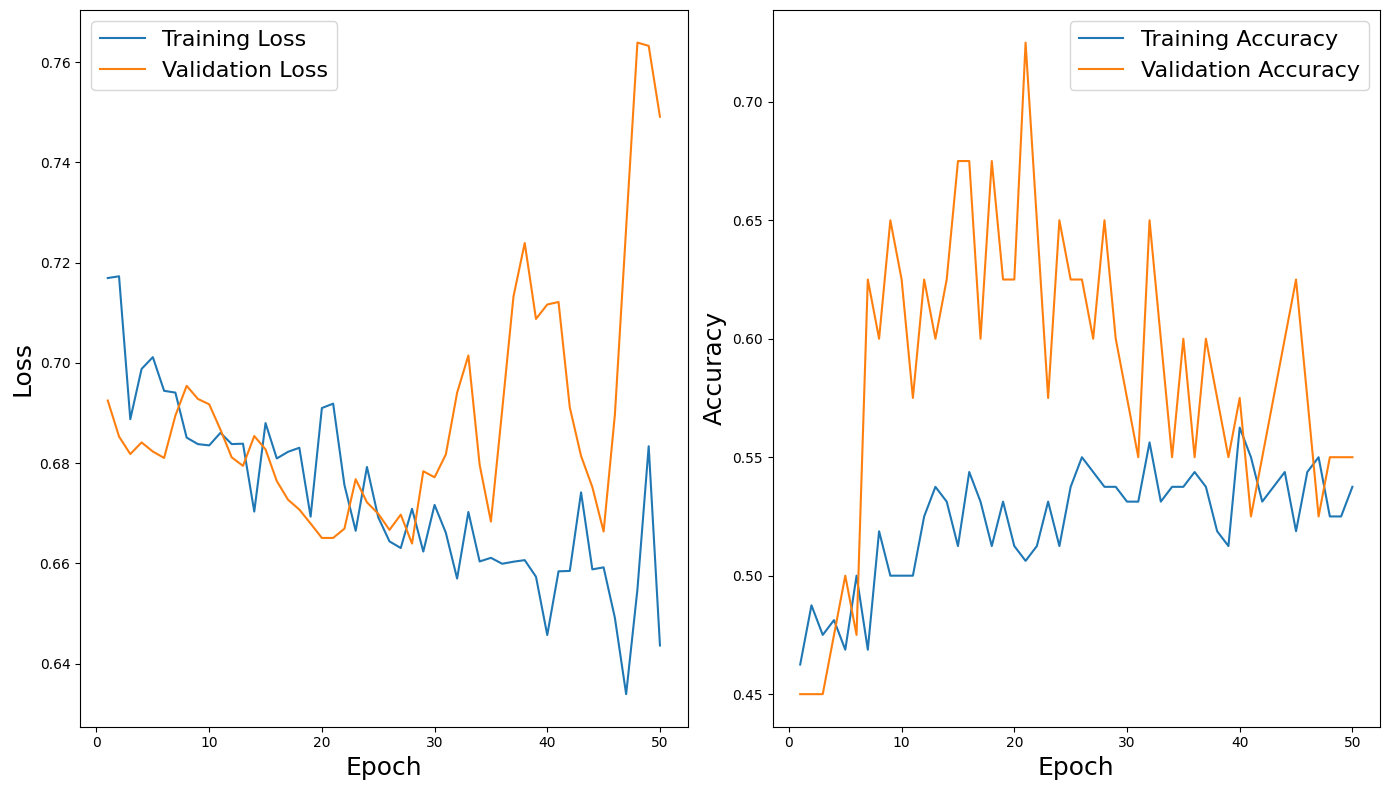

We obtained the figure below by adjusting the number of epochs in the training code to 8. As you can see, the original 8 epochs proposed by the authors did not perform very well, as the training loss did not decrease gradually, and the accuracy seemed to be very unstable as well. Because of that we chose 20 epochs for our model. This is a good cutoff point before the model starts overfitting, as the loss increases and the accuracy decreases after about 20 epochs.

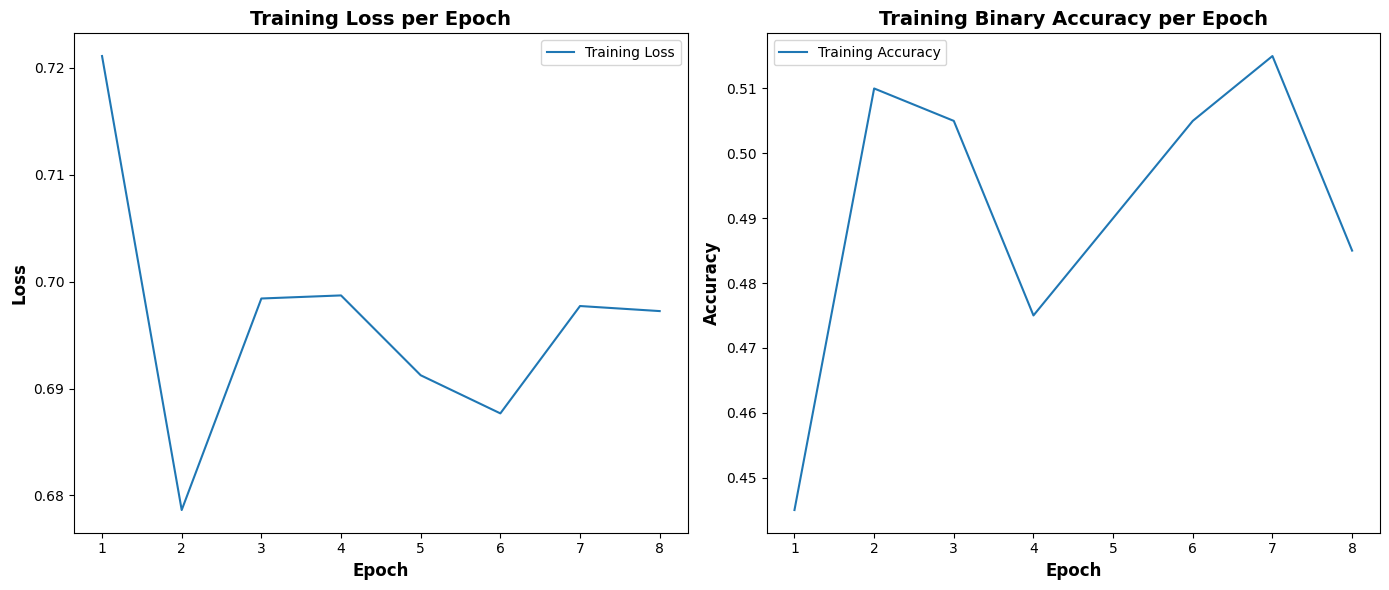


If you would like to verify the code, please run the following code chunks

*instead of the training code chunk:*
```
fin_dim_in_model = X_fin_sel_train.shape[1]
sent_dim_in_model = X_sent_sel_train.shape[1]

fin_adj_model = np.corrcoef(X_fin_sel_train, rowvar=False)
fin_adj_model = np.nan_to_num(fin_adj_model)
fin_adj_model += np.eye(fin_adj_model.shape[1]) * 0.1
fin_adj_model = fin_adj_model / (fin_adj_model.sum(axis=1, keepdims=True) + 1e-8)
fin_adj_tensor_static_model = tf.constant(fin_adj_model, dtype=tf.float32)

sent_adj_model = np.corrcoef(X_sent_sel_train, rowvar=False)
sent_adj_model = np.nan_to_num(sent_adj_model)
sent_adj_model += np.eye(sent_adj_model.shape[1]) * 0.1
sent_adj_model = sent_adj_model / (sent_adj_model.sum(axis=1, keepdims=True) + 1e-8)
sent_adj_tensor_static_model = tf.constant(sent_adj_model, dtype=tf.float32)

model = create_siagracon_sa_keras(
    fin_dim_in_model, sent_dim_in_model, int(best_params["fusion_dim"]), int(best_params["hidden"]), dropout=float(best_params["dropout"])
)

optimizer = Adam(learning_rate=float(best_params["lr"]))
criterion = BinaryCrossentropy(from_logits=True)
model.compile(optimizer=optimizer, loss=criterion, metrics=[BinaryAccuracy()])


(X_fin_inner_final, X_sent_inner_final, y_inner_final), (X_fin_val_final, X_sent_val_final, y_val_final) = \
    _time_order_split(X_fin_sel_train, X_sent_sel_train, y_train_keras, val_ratio=0.2)

train_fin_adj_batched_final = tf.tile(fin_adj_tensor_static_model[tf.newaxis, :, :], [tf.shape(X_fin_inner_final)[0], 1, 1])
train_sent_adj_batched_final = tf.tile(sent_adj_tensor_static_model[tf.newaxis, :, :], [tf.shape(X_sent_inner_final)[0], 1, 1])

train_inputs_final = {
    'fin_features': X_fin_inner_final,
    'sent_features': X_sent_inner_final,
    'fin_adjacency': train_fin_adj_batched_final,
    'sent_adjacency': train_sent_adj_batched_final
}

val_fin_adj_batched_final = tf.tile(fin_adj_tensor_static_model[tf.newaxis, :, :], [tf.shape(X_fin_val_final)[0], 1, 1])
val_sent_adj_batched_final = tf.tile(sent_adj_tensor_static_model[tf.newaxis, :, :], [tf.shape(X_sent_val_final)[0], 1, 1])

val_inputs_final = {
    'fin_features': X_fin_val_final,
    'sent_features': X_sent_val_final,
    'fin_adjacency': val_fin_adj_batched_final,
    'sent_adjacency': val_sent_adj_batched_final
}

start_time = time.perf_counter()

print("[Train] Starting Keras Model Training...")
history = model.fit(
    train_inputs_final,
    y_inner_final,
    batch_size=batch_size,
    epochs=50,
    verbose=1,
    shuffle=True,
    validation_data=(val_inputs_final, y_val_final) # Add validation data here
)
train_time = time.perf_counter() - start_time


final_loss = history.history['loss'][-1]
final_accuracy = history.history['binary_accuracy'][-1] if 'binary_accuracy' in history.history else 'N/A'
print(f"[Train] Keras training completed in {train_time:.2f} seconds.")
print(f"  - Final Training Loss: {final_loss:.4f}")
print(f"  - Final Training Accuracy: {final_accuracy:.4f}")


test_fin_adj_batched = tf.tile(fin_adj_tensor_static_model[tf.newaxis, :, :], [tf.shape(X_fin_sel_test)[0], 1, 1])
test_sent_adj_batched = tf.tile(sent_adj_tensor_static_model[tf.newaxis, :, :], [tf.shape(X_sent_sel_test)[0], 1, 1])

test_inputs = {
    'fin_features': X_fin_sel_test,
    'sent_features': X_sent_sel_test,
    'fin_adjacency': test_fin_adj_batched,
    'sent_adjacency': test_sent_adj_batched
}


print("[Prediction] Generating predictions on test set...")
logits = model.predict(test_inputs)
probs = tf.sigmoid(logits).numpy().squeeze() #
preds = (probs >= 0.5).astype(int)
print("[Prediction] Predictions generated.")
```

*instead of the fitting procedure visualization:*

```
history_data = history.history

epochs_range = range(1, len(history_data['loss']) + 1)

plt.figure(figsize=(14, 8)) # Slightly increased figure width

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_data['loss'], label='Training Loss')
plt.plot(epochs_range, history_data['val_loss'], label='Validation Loss') # Added validation loss
plt.xlabel('Epoch', fontsize=18)
plt.ylabel('Loss', fontsize=18)
plt.legend(fontsize=16)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_data['binary_accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history_data['val_binary_accuracy'], label='Validation Accuracy') # Added validation accuracy
plt.xlabel('Epoch', fontsize=18)
plt.ylabel('Accuracy', fontsize=18)
plt.legend(fontsize=16)

plt.tight_layout()

plt.show()
```

! After making changes to the code, re-run all the code with a new session

The following code is for our optimized model with 20 epochs.

In [ ]:
fin_dim_in_model = X_fin_sel_train.shape[1]
sent_dim_in_model = X_sent_sel_train.shape[1]

fin_adj_model = np.corrcoef(X_fin_sel_train, rowvar=False)
fin_adj_model = np.nan_to_num(fin_adj_model)
fin_adj_model += np.eye(fin_adj_model.shape[1]) * 0.1
fin_adj_model = fin_adj_model / (fin_adj_model.sum(axis=1, keepdims=True) + 1e-8)
fin_adj_tensor_static_model = tf.constant(fin_adj_model, dtype=tf.float32)

sent_adj_model = np.corrcoef(X_sent_sel_train, rowvar=False)
sent_adj_model = np.nan_to_num(sent_adj_model)
sent_adj_model += np.eye(sent_adj_model.shape[1]) * 0.1
sent_adj_model = sent_adj_model / (sent_adj_model.sum(axis=1, keepdims=True) + 1e-8)
sent_adj_tensor_static_model = tf.constant(sent_adj_model, dtype=tf.float32)

model = create_siagracon_sa_keras(
    fin_dim_in_model, sent_dim_in_model, int(best_params["fusion_dim"]), int(best_params["hidden"]), dropout=float(best_params["dropout"])
)

optimizer = Adam(learning_rate=float(best_params["lr"]))
criterion = BinaryCrossentropy(from_logits=True)
model.compile(optimizer=optimizer, loss=criterion, metrics=[BinaryAccuracy()])


train_fin_adj_batched = tf.tile(fin_adj_tensor_static_model[tf.newaxis, :, :], [tf.shape(X_fin_sel_train)[0], 1, 1])
train_sent_adj_batched = tf.tile(sent_adj_tensor_static_model[tf.newaxis, :, :], [tf.shape(X_sent_sel_train)[0], 1, 1])

train_inputs = {
    'fin_features': X_fin_sel_train,
    'sent_features': X_sent_sel_train,
    'fin_adjacency': train_fin_adj_batched,
    'sent_adjacency': train_sent_adj_batched
}

start_time = time.perf_counter()

print("[Train] Starting Keras Model Training...")
history = model.fit(
    train_inputs,
    y_train_keras,
    batch_size=batch_size,
    epochs=20,
    verbose=1,
    shuffle=True
)
train_time = time.perf_counter() - start_time


final_loss = history.history['loss'][-1]
final_accuracy = history.history['binary_accuracy'][-1] if 'binary_accuracy' in history.history else 'N/A'
print(f"[Train] Keras training completed in {train_time:.2f} seconds.")
print(f"  - Final Training Loss: {final_loss:.4f}")
print(f"  - Final Training Accuracy: {final_accuracy:.4f}")


test_fin_adj_batched = tf.tile(fin_adj_tensor_static_model[tf.newaxis, :, :], [tf.shape(X_fin_sel_test)[0], 1, 1])
test_sent_adj_batched = tf.tile(sent_adj_tensor_static_model[tf.newaxis, :, :], [tf.shape(X_sent_sel_test)[0], 1, 1])

test_inputs = {
    'fin_features': X_fin_sel_test,
    'sent_features': X_sent_sel_test,
    'fin_adjacency': test_fin_adj_batched,
    'sent_adjacency': test_sent_adj_batched
}


print("[Prediction] Generating predictions on test set...")
logits = model.predict(test_inputs)
probs = tf.sigmoid(logits).numpy().squeeze() #
preds = (probs >= 0.5).astype(int)
print("[Prediction] Predictions generated.")

[Train] Starting Keras Model Training...
Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - binary_accuracy: 0.4401 - loss: 0.7137
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - binary_accuracy: 0.4860 - loss: 0.6874
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - binary_accuracy: 0.5023 - loss: 0.7022
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - binary_accuracy: 0.4644 - loss: 0.7023
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - binary_accuracy: 0.4864 - loss: 0.6913
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - binary_accuracy: 0.4967 - loss: 0.6861
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - binary_accuracy: 0.5093 - loss: 0.7047
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - binary_accuracy: 0.4811 - loss: 0.6928
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - binary_accuracy: 0.4857 - loss: 0.6845
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - binary_accuracy: 0.4860 - loss: 0.6851
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - binar

## Fitting Procedure

Below we visualize the fitting procedure of our 20 epoch model.

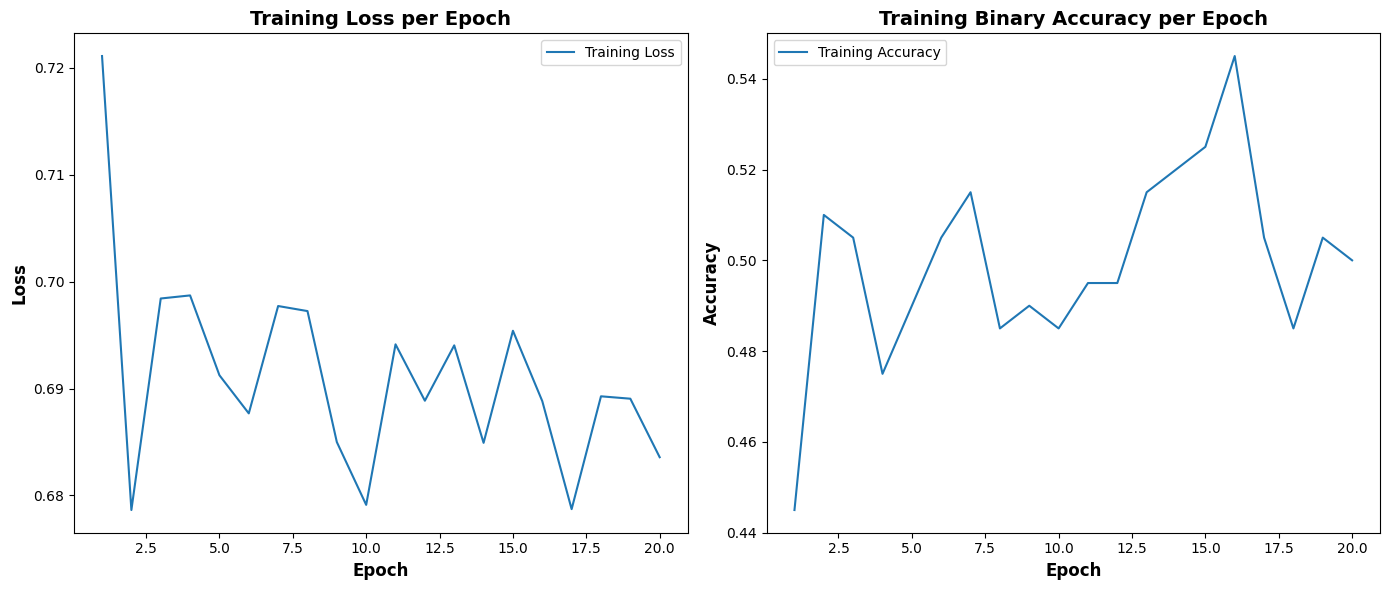

In [ ]:
history_data = history.history

epochs_range = range(1, len(history_data['loss']) + 1)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_data['loss'], label='Training Loss')
plt.title('Training Loss per Epoch', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_data['binary_accuracy'], label='Training Accuracy')
plt.title('Training Binary Accuracy per Epoch', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)

plt.tight_layout()

plt.show()

# Results

## ROC curve

To assess how well our model predicts stock price changes considering our base rate (0.549 for upwards movements), we plotted the ROC curve.

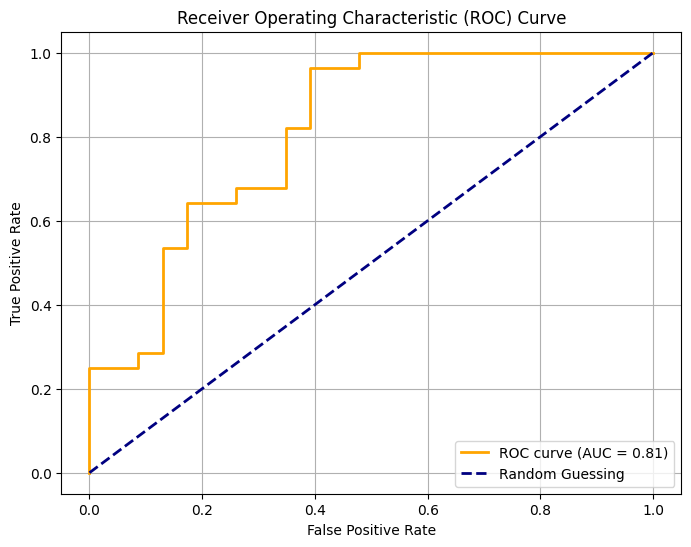

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, probs)
auc_score = roc_auc_score(y_test, probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Our AUC is 0.81, which is very good for a stock price prediction model. As the curve increases rapidly on the left, we can see that our model has high specificity in its high-confidence range. This suggests that we can avoid "false-buys" in this range. As the curve moves towards the top-right, it captures a large area at the top, indicating high overall sensitivity - correctly catching price increases. Together, our model seems to have a good balance that favors reduced risk.

## Performance Metrics

In [ ]:
base_rate = y_test.mean()
print(f"[Metrics] Base Rate (Proportion of upward movements): {base_rate:.4f}")

[Metrics] Base Rate (Proportion of upward movements): 0.5490


In [ ]:
metrics = {
    "accuracy": accuracy_score(y_test, preds),
    "precision": precision_score(y_test, preds, zero_division=0),
    "recall": recall_score(y_test, preds, zero_division=0),
    "f1": f1_score(y_test, preds, zero_division=0),
    "mse": mean_squared_error(y_test, probs),
    "mae": mean_absolute_error(y_test, probs),
}
metrics["rmse"] = float(np.sqrt(metrics["mse"]))
tn, fp, fn, tp = confusion_matrix(y_test, preds, labels=[0, 1]).ravel()
metrics["specificity"] = tn / (tn + fp + 1e-8)
metrics["params_millions"] = model.count_params() / 1e6
metrics["train_time_sec"] = train_time
print("[Performance] Model evaluation")
for k, v in metrics.items():
    print(f"  - {k}: {v:.4f}")

[Performance] Model evaluation
  - accuracy: 0.7647
  - precision: 0.7000
  - recall: 1.0000
  - f1: 0.8235
  - mse: 0.2328
  - mae: 0.4813
  - rmse: 0.4825
  - specificity: 0.4783
  - params_millions: 0.0591
  - train_time_sec: 14.8835


### Model comparisons

The metrics presented below were obtained by creating copies of this Google Colab notebook and modifying only the target stock or, in one case, the subset of tweets retained for sentiment analysis. The original code from Kumarappan et al. (2024) was executed in VS Code, as their implementation was structured as a Python script rather than a notebook format. After each model run, the resulting metrics were stored in a Python dictionary, allowing them to be easily copied and aggregated into the comparison visualization below.

For TSLA, we present three model variations. TSLA (Current Project), highlighted in green, represents our current implementation and serves as the baseline against which all other variations are compared. TSLA (Original Code, Fixed) refers to the original code from Kumarappan et al. (2024) after correcting the data leakage problem. TSLA (TSLA Tweets Only) applies the current project methodology using only TSLA-specific tweets, excluding tweets mentioning other stocks from the sentiment analysis.

For AMZN, we also present three variations. AMZN (Current Project) applies our current methodology to Amazon stock while retaining all tweets for sentiment analysis. AMZN (Original Code, Fixed), highlighted in orange, represents the original code from Kumarappan et al. (2024) applied to Amazon stock after fixing the data leakage issue. Finally, AMZN (Original Code, Leakage), highlighted in red, shows the original code with data leakage still present, resulting in an artificially inflated accuracy of 99.9%. This model demonstrates how the data duplication issue leads to misleading performance metrics.

For the remaining stocks, AAPL (Current Project) applies our methodology to Apple stock, and TSM (Current Project) applies it to Taiwan Semiconductor Manufacturing Company stock. Both models retain all tweets for sentiment analysis, following the same approach as our TSLA baseline.

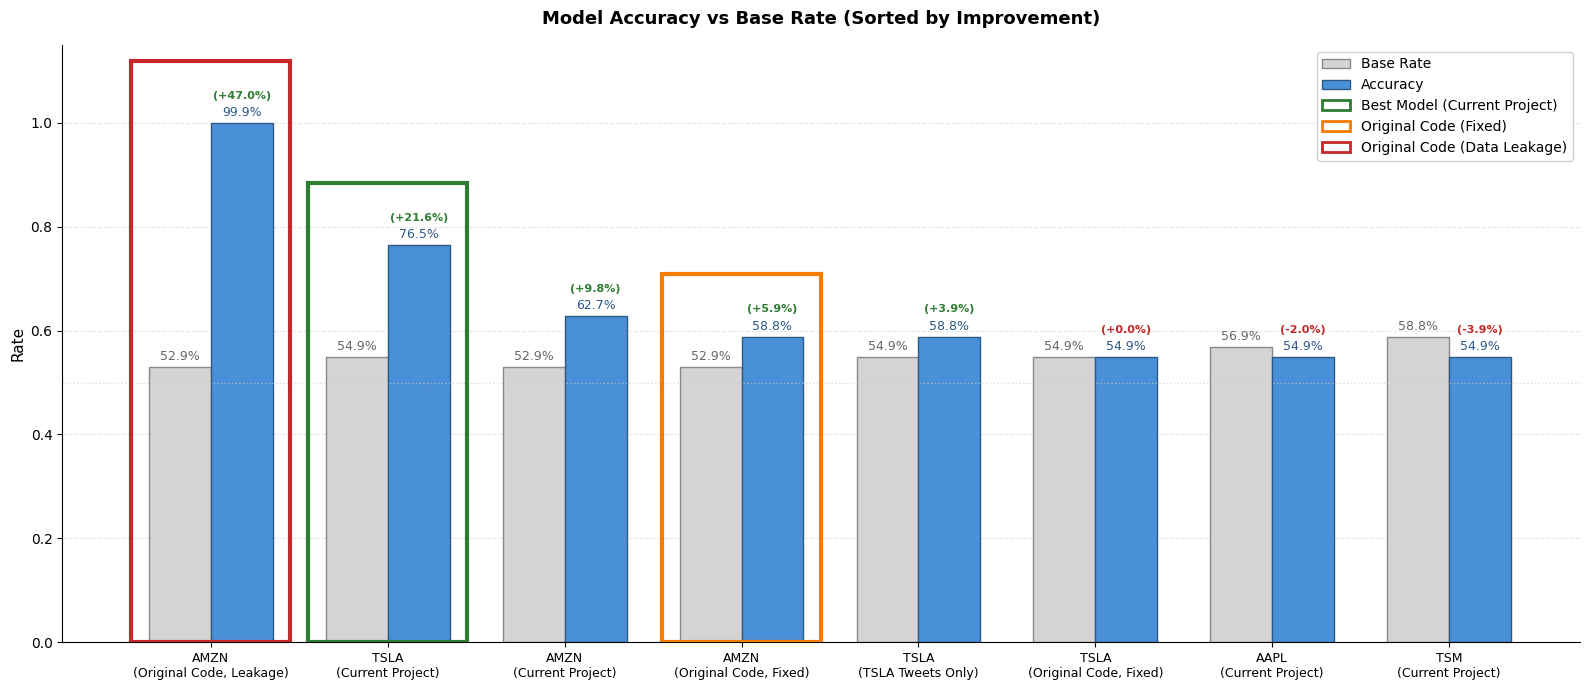

In [ ]:
ml_metrics = {'TSLA_CURRENT': {'base_rate': 0.549,
  'accuracy': 0.7647,
  'precision': 0.7,
  'recall': 1.0,
  'f1': 0.8235,
  'mse': 0.2328,
  'mae': 0.4813,
  'rmse': 0.4825,
  'specificity': 0.4783,
  'params_millions': 0.0591,
  'train_time_sec': 13.3665},
 'TSLA_CURRENT_exclusive_tweets': {'base_rate': 0.549,
  'accuracy': 0.5882,
  'precision': 0.5854,
  'recall': 0.8571,
  'f1': 0.6957,
  'mse': 0.2413,
  'mae': 0.4883,
  'rmse': 0.4912,
  'specificity': 0.2609,
  'params_millions': 0.0456,
  'train_time_sec': 17.4624},
 'TSLA_ORIGINAL': {'base_rate': 0.549,
  'accuracy': 0.549,
  'precision': 0.549,
  'recall': 1.0,
  'f1': 0.7089,
  'mse': 0.251,
  'mae': 0.4961,
  'rmse': 0.501,
  'specificity': 0.0,
  'params_millions': 0.034,
  'train_time_sec': 1.4846},
 'TSM': {'base_rate': 0.5882000000000001,
  'accuracy': 0.549,
  'precision': 0.4167,
  'recall': 0.2381,
  'f1': 0.303,
  'mse': 0.2405,
  'mae': 0.4775,
  'rmse': 0.4905,
  'specificity': 0.7667,
  'params_millions': 0.0456,
  'train_time_sec': 12.9572},
 'AAPL': {'base_rate': 0.5686,
  'accuracy': 0.549,
  'precision': 0.4828,
  'recall': 0.6364,
  'f1': 0.549,
  'mse': 0.2463,
  'mae': 0.4922,
  'rmse': 0.4963,
  'specificity': 0.4828,
  'params_millions': 0.0383,
  'train_time_sec': 11.7828},
 'AMZN': {'base_rate': 0.5294,
  'accuracy': 0.6275,
  'precision': 0.6923,
  'recall': 0.375,
  'f1': 0.4865,
  'mse': 0.2465,
  'mae': 0.4956,
  'rmse': 0.4965,
  'specificity': 0.8519,
  'params_millions': 0.0456,
  'train_time_sec': 12.9726},
   'AMZN_ORIGINAL': {
    'base_rate': 0.5294,  # Using the same base rate as AMZN since it's the same stock
    'accuracy': 0.5882,
    'precision': 0.5789,
    'recall': 0.4583,
    'f1': 0.5116,
    'mse': 0.2433,
    'mae': 0.4924,
    'rmse': 0.4933,
    'specificity': 0.7037,
    'params_millions': 0.0241,
    'train_time_sec': 0.3359
}, 'AMZN_ORIGINAL_LEAKAGE': {
    'base_rate': 0.5294,
    'accuracy': 0.999
}}


# Create clearer display names
display_names = {
    'TSLA_CURRENT': 'TSLA\n(Current Project)',
    'TSLA_CURRENT_exclusive_tweets': 'TSLA\n(TSLA Tweets Only)',
    'TSLA_ORIGINAL': 'TSLA\n(Original Code, Fixed)',
    'TSM': 'TSM\n(Current Project)',
    'AAPL': 'AAPL\n(Current Project)',
    'AMZN': 'AMZN\n(Current Project)',
    'AMZN_ORIGINAL': 'AMZN\n(Original Code, Fixed)',
    'AMZN_ORIGINAL_LEAKAGE': 'AMZN\n(Original Code, Leakage)'
}

# Define which models get highlighted boxes
highlight_boxes = {
    'TSLA_CURRENT': '#2e7d32',           # Green
    'AMZN_ORIGINAL': '#f57c00',          # Orange
    'AMZN_ORIGINAL_LEAKAGE': '#c62828'   # Red
}

# Extract data
models = list(ml_metrics.keys())
base_rates = [ml_metrics[m]['base_rate'] for m in models]
accuracies = [ml_metrics[m]['accuracy'] for m in models]
improvements = [acc - base for acc, base in zip(accuracies, base_rates)]

# Sort by improvement (biggest to smallest)
sorted_indices = np.argsort(improvements)[::-1]
models = [models[i] for i in sorted_indices]
base_rates = [base_rates[i] for i in sorted_indices]
accuracies = [accuracies[i] for i in sorted_indices]
improvements = [improvements[i] for i in sorted_indices]

# Map to display names
display_labels = [display_names[m] for m in models]

# Create figure
fig, ax = plt.subplots(figsize=(16, 7))

# Bar positions
x = np.arange(len(models))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, base_rates, width, label='Base Rate', color='#d4d4d4', edgecolor='#888888')
bars2 = ax.bar(x + width/2, accuracies, width, label='Accuracy', color='#4a90d9', edgecolor='#2d5986')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.1%}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, color='#666666')

for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax.annotate(f'{height:.1%}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, color='#2d5986')
    # Add improvement annotation
    sign = '+' if improvements[i] >= 0 else ''
    color = '#2e7d32' if improvements[i] > 0 else '#c62828'
    ax.annotate(f'({sign}{improvements[i]:.1%})', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 16), textcoords="offset points", ha='center', va='bottom', fontsize=8, color=color, fontweight='bold')

# Add highlight boxes around specific models
for i, model in enumerate(models):
    if model in highlight_boxes:
        box_color = highlight_boxes[model]
        # Create rectangle around both bars for this model
        rect = plt.Rectangle((x[i] - width - 0.1, 0), width * 2 + 0.2, max(base_rates[i], accuracies[i]) + 0.12,
                              fill=False, edgecolor=box_color, linewidth=3, linestyle='-', zorder=10)
        ax.add_patch(rect)

# Styling
ax.set_ylabel('Rate', fontsize=11)
ax.set_title('Model Accuracy vs Base Rate (Sorted by Improvement)', fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(display_labels, fontsize=9, ha='center')

# Create custom legend with highlight explanations
legend_elements = [
    mpatches.Patch(facecolor='#d4d4d4', edgecolor='#888888', label='Base Rate'),
    mpatches.Patch(facecolor='#4a90d9', edgecolor='#2d5986', label='Accuracy'),
    mpatches.Patch(facecolor='none', edgecolor='#2e7d32', linewidth=2, label='Best Model (Current Project)'),
    mpatches.Patch(facecolor='none', edgecolor='#f57c00', linewidth=2, label='Original Code (Fixed)'),
    mpatches.Patch(facecolor='none', edgecolor='#c62828', linewidth=2, label='Original Code (Data Leakage)')
]
ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9)

# Clean up chart
ax.set_ylim(0, 1.15)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add a subtle horizontal line at 0.5 for reference
ax.axhline(y=0.5, color='#cccccc', linestyle=':', linewidth=1, alpha=0.7)
fig.patch.set_facecolor('none')  # Transparent figure background
ax.set_facecolor('none')          # Transparent axes background

plt.tight_layout()
plt.show()

# Discussion

Our goal was to replicate the techniques used in the paper in order to evaluate the effectiveness of the method. Ideally, we should have been able to reproduce the entire pipeline in our own environment and arrive at the same results on outcome measures. However, this was not possible with the data and code provided.

The original paper claims to have achieved the results with NIFTY-50 from NSE, while the code and data work with US yfinance data (AMZN, TSLA, etc.). In addition, the results achieved by the paper were obtained using real-time Twitter data, while the GitHub repository used a static CSV file.

Despite the lack of data availability we tried to run the code with the data that was provided.

A few fixes were required to make it work with the most up to date pandas:
```
    - Line 68: iteritems() → items()
    - Line 83: Added numeric_only=True
    - Lines 63-66: Changed '' → 0.0 for numeric initialization
```

The script produces similar accuracies as the claims in the original paper. However this is likely due to data leakage. This occurs when information from the test set (which should be "unseen" data used to evaluate how well the model generalizes) accidentally contaminates the training process. In this code, the leakage happens through data duplication. In utils.py:186-203, there's a function that takes the original dataset and duplicates it many times:

```
x = np.concatenate([x, x, x, x, x, x, x, x, x])  # 9 copies
y = np.concatenate([y, y, y, y, y, y, y, y, y])
x = np.concatenate([x, x, x, x])  # Then 4 more copies of that
y = np.concatenate([y, y, y, y])
```

This creates copies of every data point. When the data is later split into training and testing sets (80/20 split at main.py:325), copies of the same original sample end up in both sets. The model is memorizing answers it has already seen. The duplication is hidden in a static method numpy_.array_ in utils.py, which looks like a normal NumPy function but injects this behavior when called from main.py:314-324.

Because of this the results may have been inflated in the original paper, which explains our results. Most noticeably, our accuracy is much lower (76.5%) than the accuracy found by Kumarappan et al. (2024) (99.9%).

There were differences between the two models, as we made some additions, including ..., to the preprocessing and increased the number of epochs during fitting to 20. These changes gave us a more robust model that is less prone to overfitting, than the model that we would have obtained if we simply replicated the code shared by the authors (https://github.com/jramans2/Siamese-GCN-SplitAttention-Stock-Prediction).

## Limitations

In our code and the code of the original paper, only one company is processed at a time. As Tesla had the largest amount of tweets, we decided to use Tesla for our code. However, this means that we may not find the same results for a different company, especially considering the fact that the number of tweets for the other companies are substantially lower.


## Conclusion

We were not able to replicate the code of the original paper after correcting for the data leakage, even after improving the model fitting procedure by increasing the data included and adjusting the model training.



# Division of Labor

All members participated equally on all parts (coding, designing the notebook, literature research).

# References

Galegale, N., & Shimabukuro, C. (2024). Deep Learning Applied to Stock Prices: Epoch Adjustment in Training an LSTM Neural Network. International Journal of Business and Management. https://doi.org/10.5539/ijbm.v19n4p80.

Kumarappan, J., Rajasekar, E., Vairavasundaram, S., Kotecha, K., & Kulkarni, A. (2024). Siamese Graph Convolutional Split-Attention Network with NLP based Social Sentimental Data for enhanced stock price predictions. Journal of Big Data, 11(1), Article 154. https://doi.org/10.1186/s40537-024-01016-2

Qian, Y. (2025). An enhanced Transformer framework with incremental learning for online stock price prediction. PloS One, 20(1), Article 0316955. https://doi.org/10.1371/journal.pone.0316955

Wang, C., Chen, Y., Zhang, S., & Zhang, Q. (2022). Stock market index prediction using deep Transformer model. Expert Systems with Applications, 208, Article 118128. https://doi.org/10.1016/j.eswa.2022.118128
